In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Train_table_full.csv")
df.head()

,appt_id,patient_id,nhood_id,scheduled_at,scheduled_time,appt_date,is_noshow,sms_received,lead_time_days,scheduled_date,...,is_holiday,is_before_holiday,is_after_holiday,max_temp,min_temp,precip_mm,weather,temp_range,is_rainy,nhood_freq
0,5626772,9.598513e+13,58,2016-04-27,08:36,2016-04-29,1,0,2,2016-04-27,...,0,0,0,23.4,20.8,11.9,61,2.6,1,835
1,5630279,7.336882e+14,26,2016-04-27,15:05,2016-04-29,0,0,2,2016-04-27,...,0,0,0,23.4,20.8,11.9,61,2.6,1,700
2,5630575,3.449833e+12,26,2016-04-27,15:39,2016-04-29,0,0,2,2016-04-27,...,0,0,0,23.4,20.8,11.9,61,2.6,1,700
3,5638447,5.639473e+13,2,2016-04-29,08:02,2016-04-29,1,0,0,2016-04-29,...,0,0,0,23.4,20.8,11.9,61,2.6,1,2262
4,5629123,7.812456e+13,13,2016-04-27,12:48,2016-04-29,1,0,2,2016-04-27,...,0,0,0,23.4,20.8,11.9,61,2.6,1,849


In [16]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,   # PR-AUC
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

# =========================
# 1) 데이터 로드
# =========================
df = pd.read_csv("/content/drive/MyDrive/Train_table_full.csv")

# 날짜 컬럼 파싱 & 정렬 (시간 누수 방지 목적)
df["appt_date"] = pd.to_datetime(df["appt_date"])
df = df.sort_values("appt_date").reset_index(drop=True)

# =========================
# 2) 시간 기준 70/15/15 분할
# =========================
split_70 = df["appt_date"].quantile(0.70)
split_85 = df["appt_date"].quantile(0.85)

train = df[df["appt_date"] < split_70].copy()
val   = df[(df["appt_date"] >= split_70) & (df["appt_date"] < split_85)].copy()
test  = df[df["appt_date"] >= split_85].copy()

print("Shapes:", train.shape, val.shape, test.shape)

# =========================
# 3) 타겟 생성: 노쇼=1, 정상=0
#    is_noshow가 '1=정상, 0=노쇼'였으므로 1 - is_noshow
# =========================
train["target"] = 1 - train["is_noshow"]
val["target"]   = 1 - val["is_noshow"]
test["target"]  = 1 - test["is_noshow"]

print("\nTarget ratio (train):")
print(train["target"].value_counts(normalize=True))

# =========================
# 4) 피처/라벨 분리 + 불필요 컬럼 제거
#    - ID성 컬럼 제거
#    - 원시 날짜/시간 컬럼 제거 (파생변수 dow/month 등이 이미 있음)
#    - is_noshow는 원본이므로 제거
# =========================
drop_cols = [
    "appt_id", "patient_id",   # ID
    "scheduled_at", "scheduled_time", "scheduled_date",  # 원시 스케줄
    "appt_date",               # 날짜 원본
    "is_noshow"                # 원본 라벨
]

train_model = train.drop(columns=[c for c in drop_cols if c in train.columns], errors="ignore")
val_model   = val.drop(columns=[c for c in drop_cols if c in val.columns], errors="ignore")
test_model  = test.drop(columns=[c for c in drop_cols if c in test.columns], errors="ignore")

y_train = train_model["target"]
y_val   = val_model["target"]
y_test  = test_model["target"]

X_train = train_model.drop(columns=["target"])
X_val   = val_model.drop(columns=["target"])
X_test  = test_model.drop(columns=["target"])

# =========================
# 5) 범주형 더미 처리 (날씨 포함 유지)
#    - gender, nhood_name는 object
#    - dow, month는 숫자지만 범주 의미 → 더미 권장
# =========================
categorical_cols = [c for c in ["gender", "nhood_name", "dow", "month"] if c in X_train.columns]

X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_val   = pd.get_dummies(X_val,   columns=categorical_cols, drop_first=True)
X_test  = pd.get_dummies(X_test,  columns=categorical_cols, drop_first=True)

# train 기준 컬럼 정렬 (매우 중요)
X_val  = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print("\nFeature dims:", X_train.shape, X_val.shape, X_test.shape)

# =========================
# 6) 스케일링
# =========================
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

# =========================
# 7) 로지스틱 회귀 학습 (불균형 대응)
# =========================
model = LogisticRegression(
    class_weight="balanced",
    max_iter=3000
)
model.fit(X_train_s, y_train)

# =========================
# 8) Validation 평가: ROC-AUC, PR-AUC
# =========================
y_val_proba = model.predict_proba(X_val_s)[:, 1]

roc_auc = roc_auc_score(y_val, y_val_proba)
pr_auc  = average_precision_score(y_val, y_val_proba)

baseline_pr = y_val.mean()  # 양성(노쇼=1) 비율이 PR-AUC 랜덤 기준선
print("\n[VAL Metrics]")
print(f"ROC-AUC: {roc_auc:.4f}  (random baseline=0.5)")
print(f"PR-AUC : {pr_auc:.4f}  (random baseline≈pos_rate={baseline_pr:.4f})")

# =========================
# 9) Threshold sweep (노쇼=1 기준 precision/recall/f1)
# =========================
print("\n[Threshold sweep on VAL]")
thresholds = np.arange(0.30, 0.80, 0.05)

best_t, best_f1 = None, -1
for t in thresholds:
    y_pred = (y_val_proba > t).astype(int)
    p = precision_score(y_val, y_pred)
    r = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    print(f"t={t:.2f} | Precision={p:.3f} | Recall={r:.3f} | F1={f1:.3f}")
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print(f"\nBest threshold by F1: t={best_t:.2f} (F1={best_f1:.3f})")

print(f"\n[Classification report @ t={best_t:.2f}]")
y_val_pred_best = (y_val_proba > best_t).astype(int)
print(classification_report(y_val, y_val_pred_best))

# =========================
# 10)Test 평가
# =========================
y_test_proba = model.predict_proba(X_test_s)[:, 1]
roc_auc_test = roc_auc_score(y_test, y_test_proba)
pr_auc_test  = average_precision_score(y_test, y_test_proba)
baseline_pr_test = y_test.mean()

print("\n[TEST Metrics]")
print(f"ROC-AUC: {roc_auc_test:.4f}  (random baseline=0.5)")
print(f"PR-AUC : {pr_auc_test:.4f}  (random baseline≈pos_rate={baseline_pr_test:.4f})")

y_test_pred = (y_test_proba > best_t).astype(int)
print(f"\n[Classification report on TEST @ t={best_t:.2f}]")
print(classification_report(y_test, y_test_pred))

Shapes: (75277, 31) (17567, 31) (17677, 31)

Target ratio (train):
target
0    0.790348
1    0.209652
Name: proportion, dtype: float64

Feature dims: (75277, 106) (17567, 106) (17677, 106)

[VAL Metrics]
ROC-AUC: 0.6407  (random baseline=0.5)
PR-AUC : 0.2626  (random baseline≈pos_rate=0.1861)

[Threshold sweep on VAL]
t=0.30 | Precision=0.260 | Recall=0.548 | F1=0.353
t=0.35 | Precision=0.276 | Recall=0.429 | F1=0.336
t=0.40 | Precision=0.289 | Recall=0.325 | F1=0.306
t=0.45 | Precision=0.289 | Recall=0.241 | F1=0.263
t=0.50 | Precision=0.288 | Recall=0.178 | F1=0.220
t=0.55 | Precision=0.290 | Recall=0.127 | F1=0.177
t=0.60 | Precision=0.299 | Recall=0.085 | F1=0.133
t=0.65 | Precision=0.303 | Recall=0.054 | F1=0.092
t=0.70 | Precision=0.288 | Recall=0.033 | F1=0.060
t=0.75 | Precision=0.276 | Recall=0.017 | F1=0.032

Best threshold by F1: t=0.30 (F1=0.353)

[Classification report @ t=0.30]
              precision    recall  f1-score   support

           0       0.86      0.64      0

In [18]:
X_val.dtypes[X_val.dtypes == "object"]

,0


In [11]:
from google.colab import files
import joblib
joblib.dump(model, "logistic_trainonly_model.joblib")

['logistic_trainonly_model.joblib']

In [13]:
from google.colab import files
files.download("logistic_trainonly_model.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

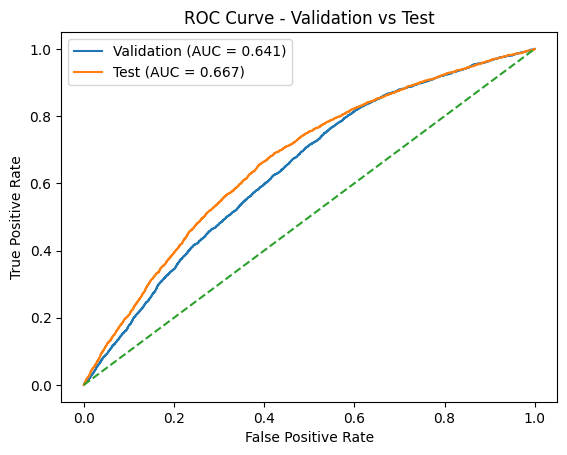

In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Validation ROC
fpr_val, tpr_val, _ = roc_curve(y_val, y_val_proba)
roc_auc_val = roc_auc_score(y_val, y_val_proba)

# Test ROC
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba)
roc_auc_test = roc_auc_score(y_test, y_test_proba)

plt.figure()

plt.plot(fpr_val, tpr_val, label=f"Validation (AUC = {roc_auc_val:.3f})")
plt.plot(fpr_test, tpr_test, label=f"Test (AUC = {roc_auc_test:.3f})")

plt.plot([0,1], [0,1], linestyle="--")  # 랜덤 기준선

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Validation vs Test")
plt.legend()
plt.show()

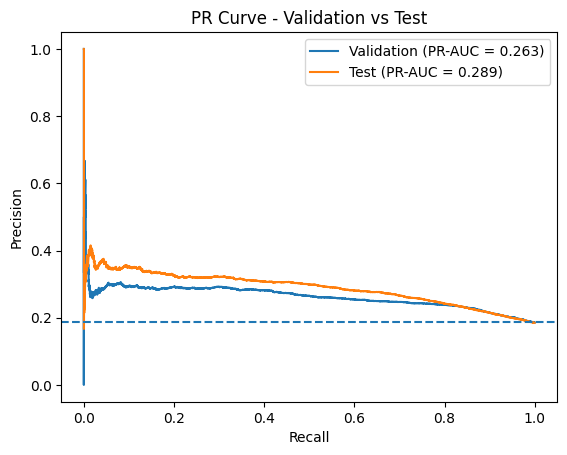

In [5]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Validation PR
precision_val, recall_val, _ = precision_recall_curve(y_val, y_val_proba)
pr_auc_val = average_precision_score(y_val, y_val_proba)

# Test PR
precision_test, recall_test, _ = precision_recall_curve(y_test, y_test_proba)
pr_auc_test = average_precision_score(y_test, y_test_proba)

plt.figure()

plt.plot(recall_val, precision_val, label=f"Validation (PR-AUC = {pr_auc_val:.3f})")
plt.plot(recall_test, precision_test, label=f"Test (PR-AUC = {pr_auc_test:.3f})")

plt.axhline(y=y_val.mean(), linestyle="--")  # baseline

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curve - Validation vs Test")
plt.legend()
plt.show()


[Top 20 Feature Importance - Absolute Coefficient]
                         feature      coef
2                 lead_time_days  0.466920
105                      month_5  0.282341
15                     precip_mm  0.250717
1                   sms_received  0.213564
3                            age -0.151800
102                        dow_3 -0.120357
101                        dow_2 -0.112968
100                        dow_1 -0.092487
52      nhood_name_ILHA DO FRADE -0.079651
56            nhood_name_ITARARÉ  0.071524
14                      min_temp  0.071326
12              is_after_holiday -0.064192
103                        dow_4 -0.062552
8                    scholarship  0.061037
85        nhood_name_SANTA LÚCIA -0.054731
89      nhood_name_SANTO ANTÔNIO  0.051514
57             nhood_name_JABOUR -0.047280
58     nhood_name_JARDIM CAMBURI -0.044901
53   nhood_name_ILHA DO PRÍNCIPE  0.039127
99      nhood_name_UNIVERSITÁRIO -0.038600


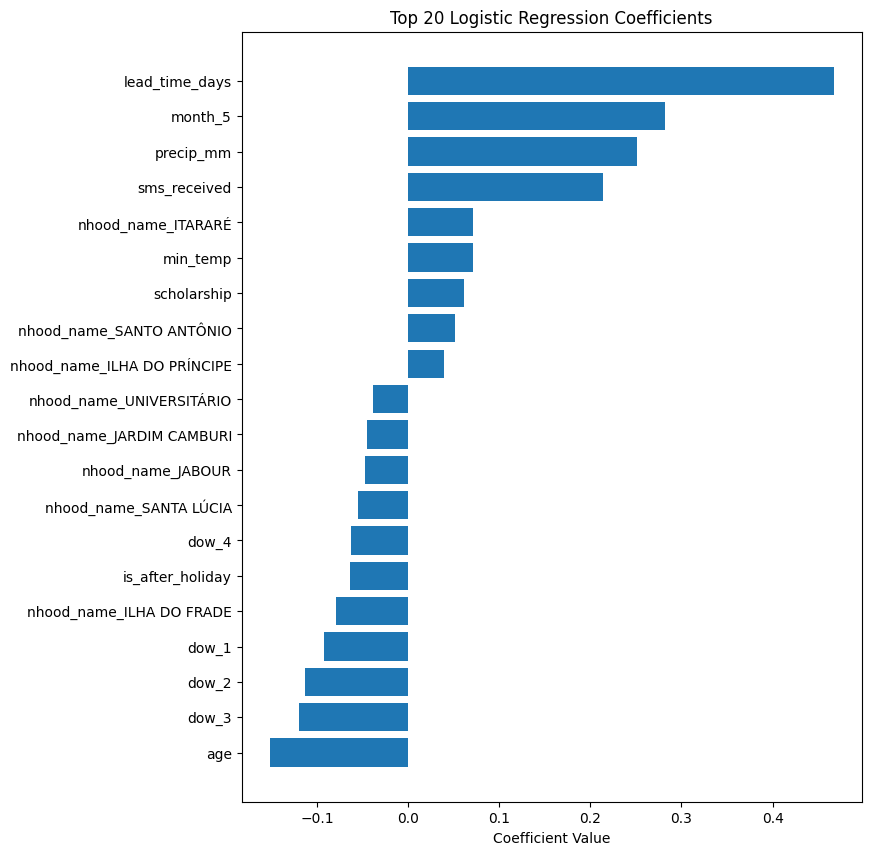

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1️) 계수 추출
# =========================
coefficients = model.coef_[0]
feature_names = X_train.columns

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coefficients,
    "abs_coef": np.abs(coefficients)
})

coef_df = coef_df.sort_values(by="abs_coef", ascending=False)

# =========================
# 2️) Top20 출력
# =========================
print("\n[Top 20 Feature Importance - Absolute Coefficient]")
top20 = coef_df.head(20)
print(top20[["feature", "coef"]])

# =========================
# 3️) 시각화
# =========================
top20_plot = top20.sort_values("coef")

plt.figure(figsize=(8,10))
plt.barh(top20_plot["feature"], top20_plot["coef"])
plt.xlabel("Coefficient Value")
plt.title("Top 20 Logistic Regression Coefficients")
plt.show()


[VAL Confusion Matrix]
 [[9203 5095]
 [1479 1790]]

[TEST Confusion Matrix]
 [[10509  3900]
 [ 1609  1659]]


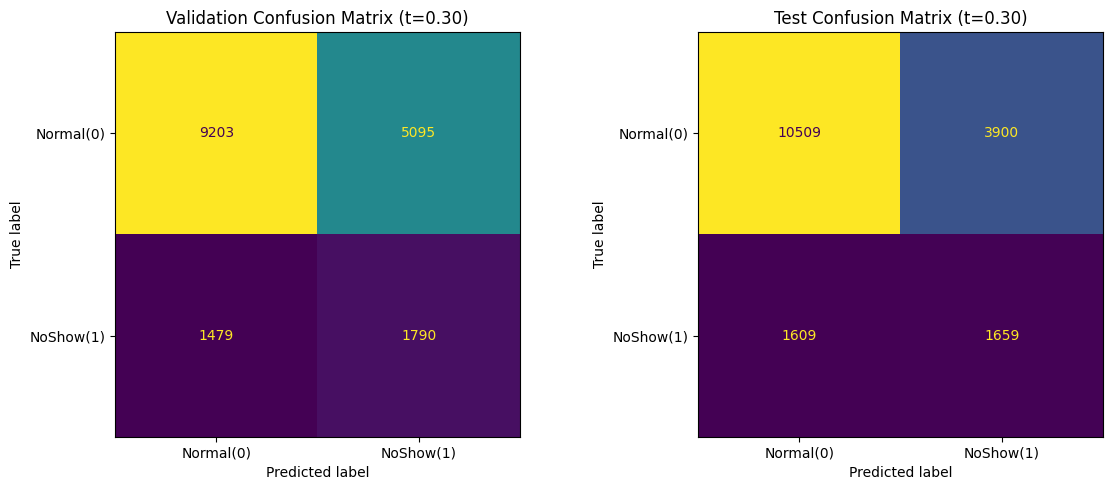

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# =========================
# 0) threshold 선택
# =========================
t = best_t  # 또는 0.30, 0.40 등 원하는 값으로 고정 가능

# =========================
# 1) 예측값 만들기
# =========================
y_val_pred  = (y_val_proba  > t).astype(int)
y_test_pred = (y_test_proba > t).astype(int)

# =========================
# 2) Confusion Matrix 계산
# =========================
cm_val  = confusion_matrix(y_val,  y_val_pred)
cm_test = confusion_matrix(y_test, y_test_pred)

print("[VAL Confusion Matrix]\n", cm_val)
print("\n[TEST Confusion Matrix]\n", cm_test)

# =========================
# 3) 시각화 (VAL vs TEST)
# =========================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(cm_val, display_labels=["Normal(0)", "NoShow(1)"]).plot(
    ax=axes[0], values_format="d", colorbar=False
)
axes[0].set_title(f"Validation Confusion Matrix (t={t:.2f})")

ConfusionMatrixDisplay(cm_test, display_labels=["Normal(0)", "NoShow(1)"]).plot(
    ax=axes[1], values_format="d", colorbar=False
)
axes[1].set_title(f"Test Confusion Matrix (t={t:.2f})")

plt.tight_layout()
plt.show()

In [19]:
X_train.columns.tolist()

['nhood_id',
 'sms_received',
 'lead_time_days',
 'age',
 'has_hypertension',
 'has_diabetes',
 'has_alcoholism',
 'has_handicap',
 'scholarship',
 'is_weekend',
 'is_holiday',
 'is_before_holiday',
 'is_after_holiday',
 'max_temp',
 'min_temp',
 'precip_mm',
 'weather',
 'temp_range',
 'is_rainy',
 'nhood_freq',
 'gender_M',
 'nhood_name_ANDORINHAS',
 'nhood_name_ANTÔNIO HONÓRIO',
 'nhood_name_ARIOVALDO FAVALESSA',
 'nhood_name_BARRO VERMELHO',
 'nhood_name_BELA VISTA',
 'nhood_name_BENTO FERREIRA',
 'nhood_name_BOA VISTA',
 'nhood_name_BONFIM',
 'nhood_name_CARATOÍRA',
 'nhood_name_CENTRO',
 'nhood_name_COMDUSA',
 'nhood_name_CONQUISTA',
 'nhood_name_CONSOLAÇÃO',
 'nhood_name_CRUZAMENTO',
 'nhood_name_DA PENHA',
 'nhood_name_DE LOURDES',
 'nhood_name_DO CABRAL',
 'nhood_name_DO MOSCOSO',
 'nhood_name_DO QUADRO',
 'nhood_name_ENSEADA DO SUÁ',
 'nhood_name_ESTRELINHA',
 'nhood_name_FONTE GRANDE',
 'nhood_name_FORTE SÃO JOÃO',
 'nhood_name_FRADINHOS',
 'nhood_name_GOIABEIRAS',
 'nhood_n

In [20]:
feature_cols = X_train.columns.tolist()

In [21]:
joblib.dump(feature_cols, "logistic_feature_cols.joblib")

['logistic_feature_cols.joblib']

In [22]:
print("saved:", "logistic_feature_cols.joblib", "len=", len(feature_cols))

saved: logistic_feature_cols.joblib len= 106


In [24]:
files.download("logistic_feature_cols.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
print(X_val.select_dtypes(include="object").columns)

Index([], dtype='object')
